# 01 — Signal Brainstorming (Skins Market Persona)
This notebook implements and sanity-checks the **Skins Market** signals (price action + volume + vol/flow).

**Signals:**
- `Float_Cap` (ATR compression / squeeze sizing)
- `Market_Crash` (volatility acceleration fade)
- `Market_Bot` (volume stability sizing)
- `Buy_Order` (channel position / breakout bias)

Assumptions:
- Signals are computed using info available at the close of day **t**.
- In backtests we’ll apply them to **next day** returns (t→t+1) to avoid lookahead.


In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 200)


## 1) Load & standardize data
We standardize to lowercase: `open/high/low/close/volume/change` and a DatetimeIndex.

In [ ]:
import numpy as np
import pandas as pd

def load_and_standardize_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Handle alternate close naming
    if "Latest" in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Latest": "Close"})

    # Parse datetime robustly (coerce bad rows -> NaT -> drop)
    if "Time" in df.columns:
        dt = pd.to_datetime(df["Time"], errors="coerce")
        df = df.assign(Date=dt).dropna(subset=["Date"]).sort_values("Date").set_index("Date")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
        df = df.assign(Date=dt).dropna(subset=["Date"]).sort_values("Date").set_index("Date")
    else:
        raise ValueError("CSV must contain a Time or Date column")

    # Standardize column names to lowercase where expected
    ren = {k: k.lower() for k in ["Open", "High", "Low", "Close", "Volume", "Change"] if k in df.columns}
    df = df.rename(columns=ren)

    # Numeric coercion (helps strip footer rows / stray strings)
    for c in ["open", "high", "low", "close", "volume", "change"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop any rows that still don't have a close
    if "close" not in df.columns:
        raise ValueError("Need close prices. Column Close/Latest missing.")
    df = df.dropna(subset=["close"])

    # Build returns (prefer Barchart-style 'Change' if present)
    if "change" in df.columns and df["change"].notna().any():
        df["prev_close"] = df["close"] - df["change"]
        df["ret"] = df["close"] / df["prev_close"] - 1.0
    else:
        df["ret"] = df["close"].pct_change()

    # Clean volume
    if "volume" in df.columns:
        df["volume"] = df["volume"].replace(0, np.nan).ffill()

    return df


DATA_PATH = r"C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw\qqq_train_validation.csv"
df = load_and_standardize_csv(DATA_PATH)
df.head()

C:\Users\brijp\AppData\Local\Temp\ipykernel_32964\284529779.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df["Time"], errors="coerce")


,Time,open,high,low,close,change,%Change,volume,prev_close,ret
Date,,,,,,,,,,
2021-01-04,1/4/21,306.1856,306.3605,296.5368,300.5499,-4.3045,-1.41%,46626427.0,304.8544,-0.014120
2021-01-05,1/5/21,299.5588,303.2998,299.5588,303.0277,2.4778,0.82%,30178082.0,300.5499,0.008244
2021-01-06,1/6/21,298.3053,303.0471,297.3142,298.8300,-4.1977,-1.39%,54348846.0,303.0277,-0.013853
2021-01-07,1/7/21,301.4924,306.8949,301.4633,306.0593,7.2293,2.42%,31280719.0,298.8300,0.024192
2021-01-08,1/8/21,308.3525,310.3444,306.1578,309.9946,3.9353,1.29%,34945507.0,306.0593,0.012858


## 2) Import signal functions
Tries common repo layouts; edit candidates if needed.

In [ ]:
import importlib.util
from pathlib import Path
import sys

SIGNALS_PATH = Path(r"C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py")

def import_signals_module(path: Path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Signals file not found: {path}")

    src_dir = str(path.parent)
    if src_dir not in sys.path:
        sys.path.insert(0, src_dir)

    spec = importlib.util.spec_from_file_location("signals_mod", str(path))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)  # type: ignore
    print(f"Loaded signals module from: {path}")
    return mod

signals_mod = import_signals_module(SIGNALS_PATH)


sig_float_cap = signals_mod.sig_flow_float_cap_atr_compression
sig_market_crash = signals_mod.sig_flow_market_crash_vol_accel_fade
sig_market_bot = signals_mod.sig_flow_market_bot_volume_stability
sig_buy_order = signals_mod.sig_pa_buy_order_channel_position


Loaded signals module from: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py


## 3) Compute signals (unshifted)

In [4]:
signals = pd.DataFrame(index=df.index)

if set(['high','low']).issubset(df.columns):
    signals['Float_Cap'] = sig_float_cap(df, high_col='high', low_col='low')
else:
    print('Skipping Float_Cap: need high/low')

signals['Market_Crash'] = sig_market_crash(df, close_col='close')

if 'volume' in df.columns:
    signals['Market_Bot'] = sig_market_bot(df, volume_col='volume')
else:
    print('Skipping Market_Bot: need volume')

if set(['high','low']).issubset(df.columns):
    signals['Buy_Order'] = sig_buy_order(df, close_col='close', high_col='high', low_col='low')
else:
    print('Skipping Buy_Order: need high/low')

signals.tail()

,Float_Cap,Market_Crash,Market_Bot,Buy_Order
Date,,,,
2025-12-01,0.209168,1.329985,0.553661,1.322803
2025-12-02,0.252877,1.500000,0.579776,1.500000
2025-12-03,0.301678,1.500000,0.564828,1.500000
2025-12-04,0.347953,1.500000,0.562663,1.500000
2025-12-05,0.392055,1.346038,0.554351,1.500000


## 4) Quick sanity checks

In [5]:
def clip_stats(s: pd.Series) -> pd.Series:
    s = s.dropna()
    if len(s) == 0:
        return pd.Series({'n': 0})
    return pd.Series({
        'n': len(s),
        'mean': s.mean(),
        'std': s.std(),
        'p_clip_low(-1)': (s <= -0.999).mean(),
        'p_clip_high(1.5)': (s >= 1.499).mean(),
        'p_zero': (np.isclose(s, 0.0)).mean(),
    })

signals.apply(clip_stats).T

,n,mean,std,p_clip_low(-1),p_clip_high(1.5),p_zero
Float_Cap,1238.0,0.478875,0.159000,0.000000,0.000000,0.025848
Market_Crash,1238.0,1.001040,0.322799,0.001616,0.091276,0.008078
Market_Bot,1238.0,0.804413,0.241593,0.000000,0.006462,0.015347
Buy_Order,1238.0,1.104420,0.509325,0.000000,0.471729,0.016155


In [6]:
signals.dropna().corr()

,Float_Cap,Market_Crash,Market_Bot,Buy_Order
Float_Cap,1.000000,0.111666,0.396206,0.328473
Market_Crash,0.111666,1.000000,0.106209,0.242988
Market_Bot,0.396206,0.106209,1.000000,0.212342
Buy_Order,0.328473,0.242988,0.212342,1.000000


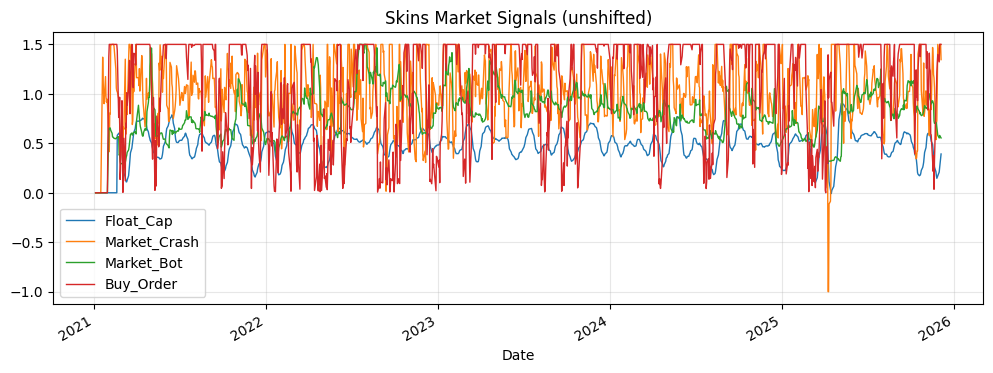

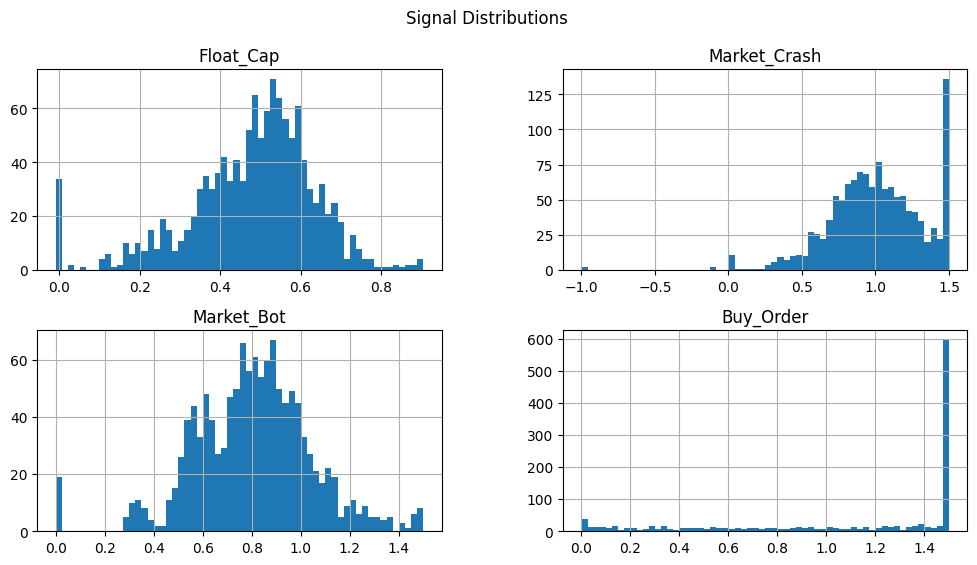

In [7]:
plt.figure(figsize=(12, 4))
signals.plot(ax=plt.gca(), linewidth=1)
plt.title('Skins Market Signals (unshifted)')
plt.grid(True, alpha=0.3)
plt.show()

signals.hist(figsize=(12, 6), bins=60)
plt.suptitle('Signal Distributions')
plt.show()